## Name: clavin dsouza
## Roll No.20 Batch:1 Class: SE/AIML
## Expt. 8: Clustering of Countries with World Bank API

In [37]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

### Part 1: Dataset

In [38]:
def fetch_indicator(code, year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]
    data={}
    for item in response:
        country = item['country']['value']
        value = item['value']
        if value is not None:
            data[country] = value
            
    return pd.Series(data, name=code)

In [39]:
gdp=fetch_indicator("NY.GDP.PCAP.CD")
pop=fetch_indicator("SP.POP.TOTL")
life= fetch_indicator("SP.DYN.LE00.IN")
lit=fetch_indicator("SE.ADT.LITR.ZS")

In [40]:
df=pd.concat([gdp, pop, life, lit], axis=1)

#Define new column name
df.columns=['GDP', 'Population', 'LifeExpectancy', 'Literacy']

#Remove missing values
df.dropna(inplace=True)
df.head()

#print("India:", "India" in df.index)
#print(df.loc["India"])


,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

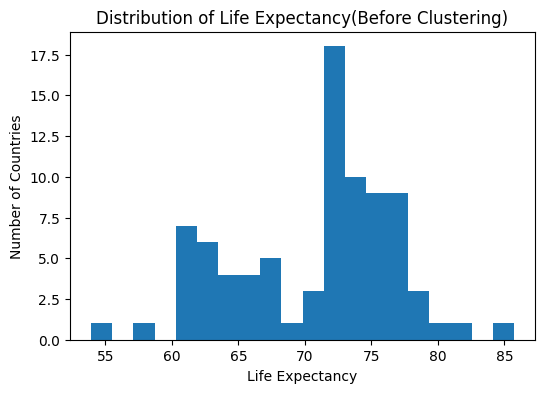

In [42]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy(Before Clustering)")
plt.show()

### Part 2

k	WCSS
1 	 336
2 	 206
3 	 142
4 	 122
5 	 69
6 	 56
7 	 51
8 	 42
9 	 31
10 	 27


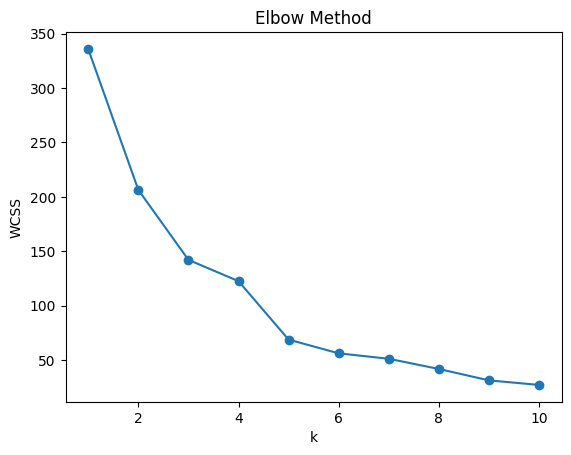

In [43]:
wcss=[]
for k in range(1,11):
    km=KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    
print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", round(wcss[i]))

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Part 3: Clustering Algorithm

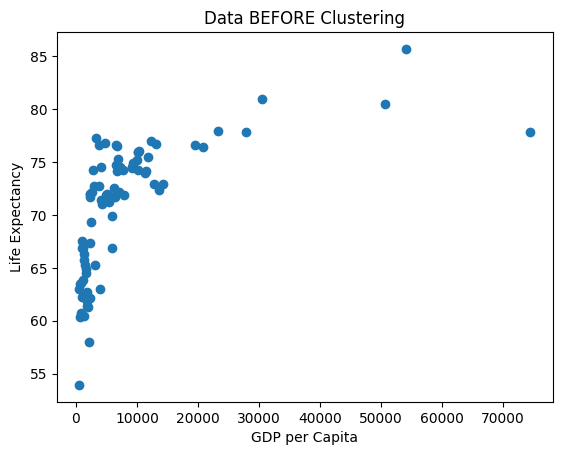

In [44]:
plt.scatter(df["GDP"], df["LifeExpectancy"])

plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("Data BEFORE Clustering")
plt.show()


In [45]:
kmeans = KMeans(n_clusters=3, random_state=0)

#label the clusters means give numbers to them and add it as column KMeansCluster
labels_km=kmeans.fit_predict(X_scaled)
df["KMeansCluster"] = labels_km

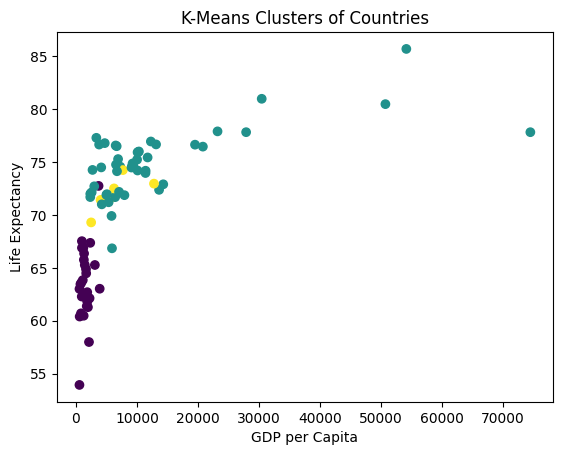

In [46]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")
plt.show()

In [47]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchicalCluster"] = labels_hc

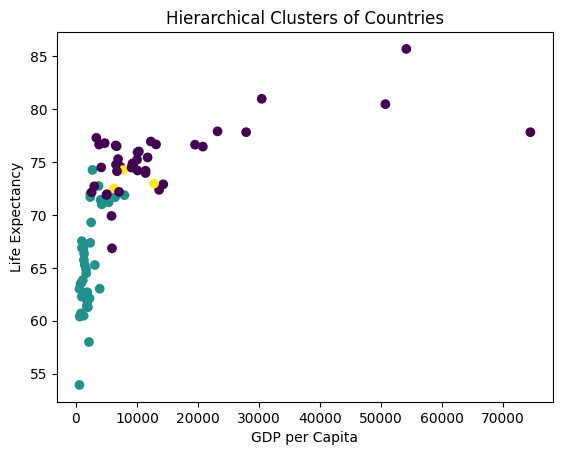

In [48]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clusters of Countries")
plt.show()

### Part 4

In [49]:
country_name="India"
result=df.loc[country_name]
print("Country:", country_name)
print("GDP per Capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy:", result["Literacy"])
print("K-Means Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per Capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy: 76.3199996948242
K-Means Cluster: 1.0
Hierarchical Cluster: 1.0


In [50]:
country_name="North America"
result=df.loc[country_name]
print("Country:", country_name)
print("GDP per Capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy:", result["Literacy"])
print("K-Means Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP per Capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy: 98.7891464233398
K-Means Cluster: 1.0
Hierarchical Cluster: 0.0


In [51]:
country_name="Brazil"
result=df.loc[country_name]
print("Country:", country_name)
print("GDP per Capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy:", result["Literacy"])
print("K-Means Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP per Capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy: 94.3853874531348
K-Means Cluster: 1.0
Hierarchical Cluster: 0.0


In [52]:
country_name="Viet Nam"
result=df.loc[country_name]
print("Country:", country_name)
print("GDP per Capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy:", result["Literacy"])
print("K-Means Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP per Capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy: 96.129997253418
K-Means Cluster: 1.0
Hierarchical Cluster: 0.0


In [53]:
country_name="Bahrain"
result=df.loc[country_name]
print("Country:", country_name)
print("GDP per Capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy:", result["Literacy"])
print("K-Means Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP per Capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy: 97.870002746582
K-Means Cluster: 1.0
Hierarchical Cluster: 0.0


In [54]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687
